# This code demonstrates the simulations used for the chapter on scaling in a growing tissue patterning with a GRN, with a growing morphogen source 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numba
import sys
import math
import json
import os
import yaml
from scipy.interpolate import CubicSpline
# plotting
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colorsys
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import dill as pickle

# import FuncToggle
import FuncPatternQuant.dimensional as dimFuncPatternQuant
import FuncPatternQuant.nondimensional4D as nd4FuncPatternQuant
import FuncToggle.dimensional as dimFuncToggle
import FuncToggle.nondimensional4D as nd4FuncToggle
import FuncAnalytical.dimensional as dimFuncAnalytical
import FuncAnalytical.nondimensional4D as nd4FuncAnalytical
import FuncPatternQuant.nondimensional3D as nd3FuncPatternQuant
import FuncToggle.nondimensional3D as nd3FuncToggle
import FuncAnalytical.nondimensional3D as nd3FuncAnalytical
import FuncDim

In [ ]:
# change time units to be t_factor * seconds
# e.g. if t_factor = 100, the unit of time is centiseconds.
# so every rate must be multipled by t_factor (g, D, k, VM, V1, V2, k1, k2)
t_factor = 10000

# %%%%%%%%%%%%%%%%%%%%% Physical Parameters %%%%%%%%%%%%%%%%%%%%%
# %%%%%%%%%% tissue & growth parameters %%%%%%%%%%
L0 = 100 # initial length of tissue, um 
Lf = 1000 # final length of tissue, um
epsilon = 0.8 # anisotropy parameter, dimensionless
# g_max = 0.000005 * t_factor # maximum growth rate, (t_factor s)^-1
g_max = 0.0000025 * t_factor # maximum growth rate, (t_factor s)^-1



# %%%%%%%%%% morphogen parameters %%%%%%%%%%
D = 0.2 * t_factor # diffusion coefficient, um^2/(t_factor s)
k = 0.0004 * t_factor # degradation rate, (t_factor s)^-1
sourceSize0 = 10 # size of morphogen source, um
VM = 0.0023 * t_factor # um/(t_factor s)

# %%%%%%%%%% morphogen source growth parameters %%%%%%%%%%
gamma = 1
beta = sourceSize0* L0**(-gamma)

# %%%%%%%%%% GRN parameters %%%%%%%%%%
# V1, V2 = 0.000606375, 0.004425
# k1, k2 = 0.00001, 0.000075


# V1 = 0.01 * t_factor # production rate of gene 1,  (t_factor s)^-1
# V2 = 0.0055 * t_factor # production rate of gene 2,  (t_factor s)^-1

V1 = 0.009523809523809523 * t_factor # production rate of gene 1,  (t_factor s)^-1
V2 = 0.0009322033898305084 * t_factor # production rate of gene 2,  (t_factor s)^-1

k1 = 0.00005 * t_factor # degradation rate of gene 1, (t_factor s)^-1
k2 = 0.00005 * t_factor # degradation rate of gene 2, (t_factor s)^-1


q, p, h = 2, 2, 3

# Mstar = 1.4
# N1star = 21/20
# N2star = 5.9
# Mstar, N1star, N2star = 1, 1.05, 5.9
Mstar, N1star, N2star = 1, 1, 1




# non dimensionalise parameters
vm, v1, v2 = FuncDim.find_nd3_parameters(VM, Mstar, V1, N1star, V2, N2star)


# %%%%%%%%%%%%%%%%%%%%% Simulation Parameters %%%%%%%%%%%%%%%%%%%%%
N = 201
t_max = (1+epsilon)*np.log(Lf/L0)/(g_max)
dt_factor = 0.95
store_no = 500 # the number of counts at which I store the results
store_no_ng = 1000 # the number of counts at which I store the results for no growth case


x0 = np.linspace(0,L0,N)
m_init = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize0,N,L0,x0,ratio_given=False)
n1_init = np.zeros(N)
n2_init = np.zeros(N)
chi_0 = 0.3*L0 # initiate a boundary 
n1_init[:int(N*chi_0/L0)] = (v1/k1)
n2_init[int(N*chi_0/L0):] = (v2/k2)


# final space
xf = np.linspace(0,Lf,N)
# patterning threshold
fraction = 0.8 # for threshold of boundary 


# calculate simulation parameters
N_1, N_2, dy, w0, dt, count_max, dt_store = FuncDim.calculate_useful_simulation_parameters(N,L0,dt_factor,D,k,g_max,k1,k2,sourceSize0,t_max,store_no)
N_1, N_2, dy, w0, dt_ng, count_max_ng, dt_store_ng = FuncDim.calculate_useful_simulation_parameters_no_growth(N,L0,dt_factor,D,k,k1,k2,sourceSize0,store_no_ng,t_max_factor = 10)

# save a dictionary for the system parameters
System_Parameters = {"D":D/t_factor,"k":k/t_factor,"VM":VM/t_factor,"L0":L0,"Lf":Lf,"initialSourceSize":sourceSize0,"beta":beta,"gamma":gamma,"epsilon":epsilon,"V1":V1/t_factor,"V2":V2/t_factor,"k1":k1/t_factor,"k2":k2/t_factor,"Mstar":Mstar,"N1star":N1star,"N2star":N2star,"q":q,"p":p,"h":h,"g":g_max/t_factor,"fraction":fraction}
System_Parameters_nd = {"D":D/t_factor,"k":k/t_factor,"VM":VM/t_factor,"L0":L0,"Lf":Lf,"initialSourceSize":sourceSize0,"beta":beta,"gamma":gamma,"epsilon":epsilon,"v1":v1/t_factor,"v2":v2/t_factor,"k1":k1/t_factor,"k2":k2/t_factor,"q":q,"p":p,"h":h,"g":g_max/t_factor,"fraction":fraction}

Simulation_Parameters = {"dt":dt,"N":N,"dt_store":dt_store,"t_max":t_max,"dt_ng":dt_ng}



# save the parameters as .npy files
# np.save('ParametersUsed/Fig4_System_Parameters.npy', System_Parameters)
# np.save('ParametersUsed/Fig4_Simulation_Parameters.npy', Simulation_Parameters)


# plt.fill_between(x0, m_ana_0, where=(m_ana_0>m_critical1) & (m_ana_0<m_critical2), color=bistable_colour, alpha=0.5)
print("no of stores_ng",math.ceil(count_max_ng/store_no_ng))
print("no of stores",math.ceil(count_max/store_no))


# stability checks
FuncDim.von_Neumann_and_growth_check(dt, D, dy, k, g_max, k1, k2, epsilon)
FuncDim.growth_dy_check(L0,Lf,N)
System_Parameters
lam = np.sqrt(D/k) # characteristic length scale of morphogen gradient
# find non dimensional morphogen profile and critical values
m_ana_f = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize0,N,Lf,xf,ratio_given=False)
m_ana_0 = nd3FuncAnalytical.find_m_ana_SS(vm,k,D,sourceSize0,N,L0,x0,ratio_given=False)

c1_critical1_nd, c1_critical2_nd, m_critical1, m_critical2 = nd3FuncToggle.find_critical_m_values(v1, v2, k1, k2, q, p, h, estimate_ratio=1)

n1_amp_eff = v1 * nd3FuncToggle.pos_hill_function(np.max(m_ana_f),h) / (k1 + g_max) 
n2_amp_eff = v2 / (k2 + g_max)

x_critical1_0 = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_0,m_critical1,x0,N)
x_critical2_0 = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_0,m_critical2,x0,N)
x_critical1 = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_f,m_critical1,xf,N)
x_critical2 = nd4FuncToggle.find_x_critical_from_m_critical(m_ana_f,m_critical2,xf,N)

plt.plot(x0,m_ana_0,color='k')
plt.plot(x0,m_init,color='k')

plt.plot(xf,m_ana_f,color=M_colour)
plt.xlim(xmax=300)
plt.xlabel('$x$ $(\\mathrm{\\mu m})$')
plt.ylabel(f'$m$ ')

plt.axhline(m_critical1,c='k',ls='--')
plt.axhline(m_critical2,c='k',ls='--')

growth stability 1.3187438617678803e-05
vN 1.9000237373895117
Stable
initial dy, final dy 0.5 2.5
20.0 0.85 100.0 20 201 100
k sim 0.00085
  real 0.00022 /s source Benzinger and Briscoe 2025
lambda sim 10.846522890932809
  real 25 μm source Benzinger and Briscoe 2025
growth rate sim 2e-05
  real 1e-05 /s source Kicheva et al. 2014
tissue length sim 100
  real 100 μm source Kicheva et al. 2014
anisotropy parameter sim 0.8
  real 0.6 - source Kicheva et al. 2014
GRN production rates sim (0.003806375, 0.003525)
  real 7.5e-05 conc/s source Rayon et al. 2020
GRN degradation rates sim (5e-06, 7.5e-05)
  real 2.5e-05 /s source Balaskas et al. 2012


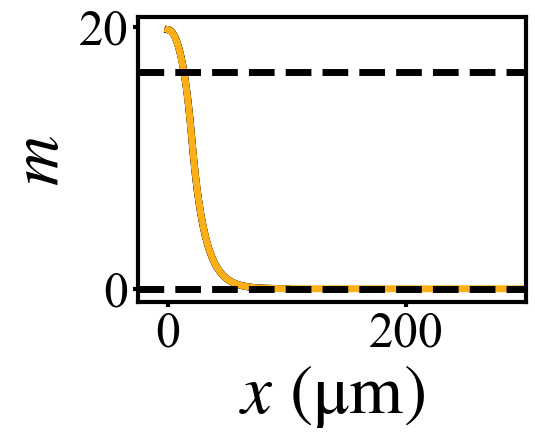

In [ ]:
plt.plot(x0,m_ana_0,color='k')
plt.plot(x0,m_init,color='k')

plt.plot(xf,m_ana_f,color='yellow')
plt.xlim(xmax=300)
plt.xlabel('$x$ $(\\mathrm{\\mu m})$')
plt.ylabel(f'$m$ ')

plt.axhline(m_critical1,c='k',ls='--')
plt.axhline(m_critical2,c='k',ls='--')
# plt.fill_between(x0, m_ana_0, where=(m_ana_0>m_critical1) & (m_ana_0<m_critical2), color='lilac', alpha=0.5)


In [ ]:
timeArray_1D_sg, xArray_1D_sg, mArray_1D_sg, n1Array_1D_sg, n2Array_1D_sg, x_YArray_1D_sg, LArray_1D_sg, wArray_1D_sg = nd3FuncToggle.n1n2m_solver_ConstantGrowth_scale_source(N,N_1,N_2,w0,D,k,vm,epsilon,beta,gamma,dt,dy,v1,v2,k1,k2,h,p,q,L0,store_no,m_init,n1Array_ng_0_eff[-1,:],n2Array_ng_0_eff[-1,:],count_max,g_max)
sourceSizeArray = beta * LArray_1D_sg**gamma
n1_boundaryArray_1D_sg = dimFuncPatternQuant.find_gene_boundaryArray(n1Array_1D_sg,xArray_1D_sg,sourceSize0,fraction,norm_value=n1_amp_eff,scaledsource=True)
n2_boundaryArray_1D_sg = dimFuncPatternQuant.find_gene_boundaryArray(n2Array_1D_sg,xArray_1D_sg,sourceSize0,fraction,norm_value=n2_amp_eff,scaledsource=True)